# Credit-Risk Scorecard with a Decision Tree (PROC HPSPLIT)

## Executive Summary

This notebook builds an interpretable credit-default scorecard for a retail loan book using PROC HPSPLIT. We grow a classification tree with the entropy criterion on synthetic applicant data, prune it by cost-complexity, then read off the fit statistics, variable importance, the ROC/AUC, and the scoring tree itself — exactly the transparent, regulator-friendly model a bank's risk team would document. Every applicant can be scored to a leaf, and the whole tree can be exported as deployable DATA step code.

## Data Sources

| Dataset | Rows | Description | Key variables |
|---------|------|-------------|---------------|
| `applicants` | 100 | Synthetic retail-loan applicants generated inline with `rand()`. The binary `default` flag is drawn from a logistic risk score so that worse DTI, utilization, recent delinquencies, and shorter credit history raise default probability. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (own/rent/mortgage), `purpose` (debt/home/auto/other) |

The DATA step loops `id = 1` to `100`, so the applicant book is exactly 100 rows — a compact, fully reproducible portfolio that is plenty to grow and read an interpretable scorecard tree.

# Credit-Risk Scorecard with a Decision Tree

Banks need default models that are **accurate and explainable** — a credit officer (and a regulator) must be able to trace exactly why an applicant was scored high-risk. A pruned decision tree delivers that: every prediction is a short chain of human-readable splits.

In this notebook we:

1. Synthesize a retail-loan application book.
2. Grow a classification tree with `PROC HPSPLIT` using the entropy criterion.
3. Prune it by cost-complexity to avoid overfitting.
4. Inspect the fit statistics, variable importance, the ROC/AUC, and the tree itself.
5. Emit DATA step scoring code that can be deployed against new applications.

## 1. Generate the synthetic loan book

We generate applicants whose probability of default is a logistic function of the classic scorecard drivers: debt-to-income ratio, revolving utilization, FICO score, length of credit history, and recent delinquencies. We then draw the observed `default` flag from a Bernoulli with that probability, so the signal is real but noisy — just like production data. The DATA step builds 100 applicants.

                                                   The FREQ Procedure

default    Frequency    Percent
--------------------------------
0                 79     79.00
1                 21     21.00

home        Frequency    Percent
---------------------------------
mortgage           34     34.00
own                31     31.00
rent               35     35.00

purpose    Frequency    Percent
--------------------------------
auto              23     23.00
debt              37     37.00
home              28     28.00
other             12     12.00


NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


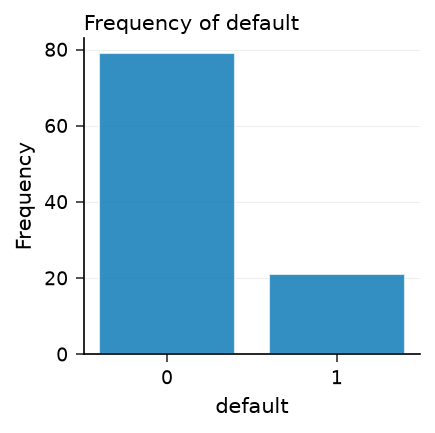

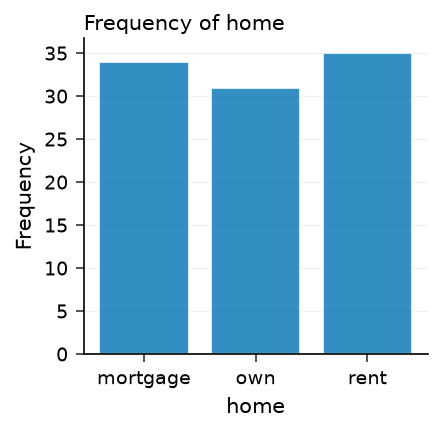

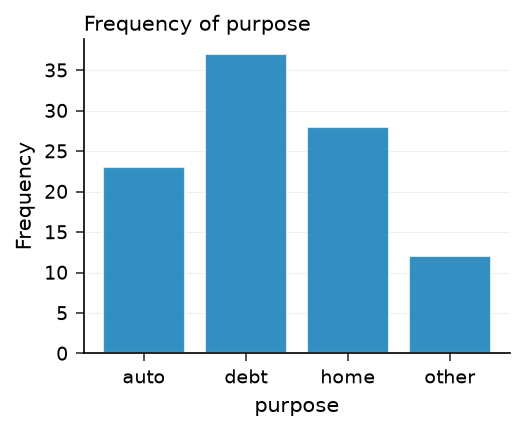

In [1]:
data applicants;
   call streaminit(20260531);
   length home $8 purpose $6;
   do id = 1 to 100;
      /* Borrower financial profile */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Categorical attributes */
      u = rand('uniform');
      if u < 0.34 then home = 'rent';
      else if u < 0.70 then home = 'mortgage';
      else home = 'own';

      v = rand('uniform');
      if v < 0.40 then purpose = 'debt';
      else if v < 0.65 then purpose = 'home';
      else if v < 0.85 then purpose = 'auto';
      else purpose = 'other';

      /* Latent default risk: worse DTI/utilization/delinquency and
         lower FICO / shorter history all raise the log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'rent')
            + 0.25 * (purpose = 'debt');
      p = 1 / (1 + exp(-eta));
      default = (rand('uniform') < p);

      drop u v eta p;
      output;
   end;
run;

proc freq data=applicants;
   tables default home purpose / nocum;
run;

The `PROC FREQ` output confirms an imbalanced but workable default rate — about one applicant in five defaults (21 of 100) — and a sensible spread across home-ownership and loan-purpose categories: the kind of marginal distribution you would expect in a consumer-lending portfolio. The accompanying bar charts visualize each marginal.

## 2. Grow and prune the scorecard tree

We model `default` as a binary classification target, naming `event='1'` so that all sensitivity/specificity/AUC statistics are oriented toward the *default* class. We:

- declare the categorical predictors and the response in `CLASS`,
- grow the tree with the **entropy** (information-gain) criterion,
- prune by **cost-complexity** to keep the tree from memorizing noise,
- request the **whole-tree diagram** and the **ROC curve**.


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
UTILIZATION                    0.384468       0.384468
FICO                           0.334699       0.33

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


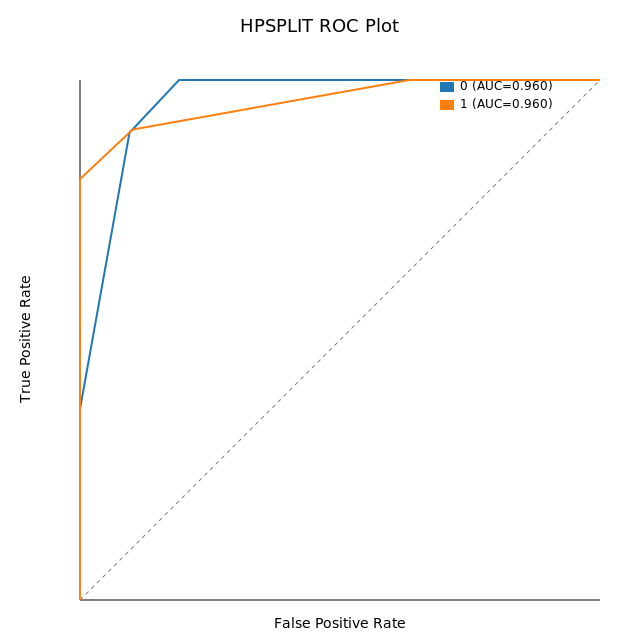

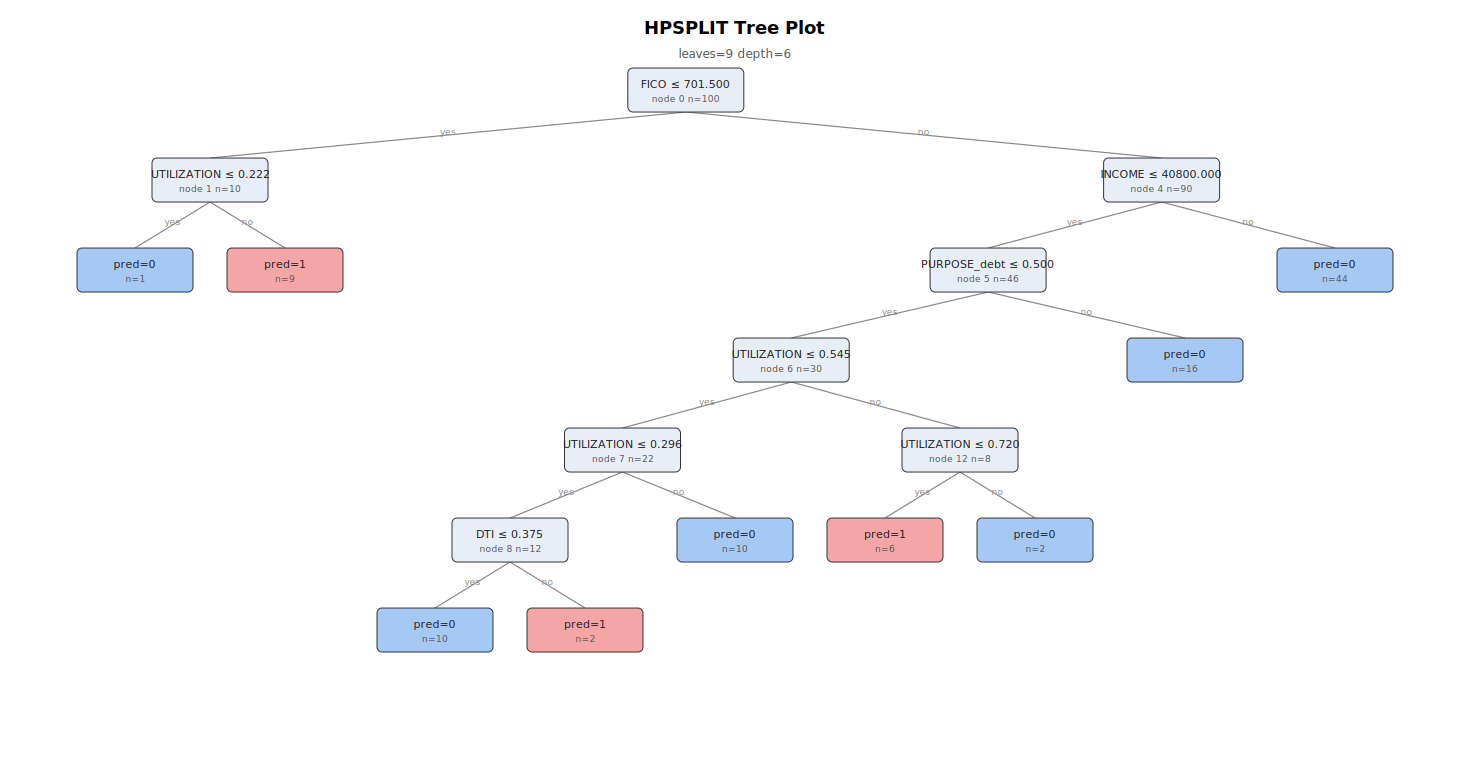

In [2]:
ods graphics on;

proc hpsplit data=applicants seed=20260531
             plots=(wholetree roc);
   class default home purpose;
   model default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
run;

The **Fit Statistics** (accuracy, misclassification rate, log loss) and the **ROC / AUC by class** tell you how cleanly the pruned tree separates defaulters from non-defaulters. The **Variable Importance** table ranks which attributes drive the splits — here **utilization** and **FICO** dominate, followed by **loan purpose**, exactly the levers a credit policy would emphasize. The **whole-tree plot** below lays out the chosen splits as a node-link diagram: each internal node shows its `feature ≤ threshold` rule, and each leaf is colored by its predicted class (red = predicted default, blue = predicted non-default) and labeled with its sample count.

## 3. Zoom in on the headline splits and score each applicant

The ROC plot above visualizes the trade-off between catching defaulters and false alarms; the AUC quantifies overall ranking power. Next we magnify the top two levels of the tree — the highest-information splits an analyst would translate into headline underwriting rules — and capture per-observation scores to an output dataset so we can audit predictions downstream.


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
UTILIZATION                    0.384468       0.384468
FICO                           0.334699       0.33

NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/47b3313e-1858-4754-8c04-9a94008f2e2c/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


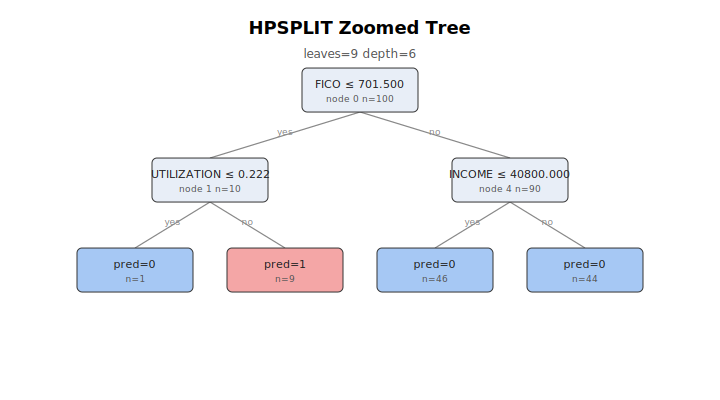

In [3]:
proc hpsplit data=applicants seed=20260531
             plots=zoomedtree(nodes=('0') depth=2);
   class default home purpose;
   model default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   output out=scored;
run;

proc print data=scored(obs=10);
   var p_default1 _node_ _leaf_;
run;

The `zoomedtree` plot magnifies the top two levels of the tree — the highest-information splits an analyst would translate into headline underwriting rules. The `OUTPUT OUT=` dataset carries each applicant's predicted default probability (`P_DEFAULT1`) plus the assigned node and leaf (`_NODE_`, `_LEAF_`), so risk and audit teams can trace any individual decision back through the tree and rank applicants by modeled risk.

## 4. Export deployable scoring code

The value of an interpretable model is that it ships. `CODE FILE=` writes a self-contained DATA step — a nested chain of `IF/THEN` splits ending in a predicted default probability and class — that reproduces the tree's score for any new application file with no model server required.

In [4]:
proc hpsplit data=applicants seed=20260531;
   class default home purpose;
   model default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code file='credit_scorecard.sas';
run;


                                                 The HPSPLIT Procedure                                                  

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          6

Fit Statistics
  accuracy                   0.960000
  misclass_rate              0.040000
  log_loss                   0.131399

ROC / AUC by Class
Class                               AUC
0                              0.960217
1                              0.960217

Variable Importance
Variable                     Importance       Relative
UTILIZATION                    0.384468       0.384468
FICO                           0.334699       0.33

NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpreting the results

The pruned entropy tree gives the risk team a compact, auditable credit scorecard:

- **The splits encode policy.** The dominant splits — on revolving utilization and FICO, then loan purpose and DTI — are precisely the thresholds an underwriting team can lift into hard cut-off rules. The whole-tree plot lays out every split condition and leaf in one diagram.
- **Cost-complexity pruning** keeps the tree from memorizing noise; the fit statistics (accuracy, misclassification rate, log loss) summarize how cleanly it separates the two classes.
- **Variable importance and the ROC/AUC** justify which attributes earn a place in the scorecard and document its discriminatory power for model-risk governance.
- **`CODE FILE=` makes it operational** — the emitted DATA step scores new applicants identically to this run, so the model that was built is exactly the model that goes live.

On a small applicant book the tree fits the training data tightly; in production you would grow it on the full portfolio, hold out a validation partition, calibrate the probability cut-off to the bank's expected-loss economics (the cost of a missed default versus a declined good customer) rather than a naive 0.5, and refresh the tree as the portfolio mix shifts.